# 08 – Análisis Exploratorio de Datos (EDA)

En este notebook se analiza el archivo:

`../data/processed/training_dataset.parquet`

## Objetivos

- Verificar la integridad del dataset
- Revisar tipos de datos y cobertura temporal
- Identificar valores faltantes
- Explorar patrones de producción de leche
- Detectar señales útiles para modelado
- Documentar observaciones y conclusiones preliminares


## 1. Importaciones y configuración

Se cargan las librerías principales para análisis tabular y visualización.  
También se ajustan algunas opciones para mostrar todas las columnas disponibles.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)


## 2. Carga del dataset

En esta sección se lee el dataset procesado que servirá como base para el análisis.  
El objetivo es revisar rápidamente su tamaño, algunas filas de ejemplo y estadísticas descriptivas iniciales.


In [2]:
PATH = "../data/processed/training_dataset.parquet"

df = pd.read_parquet(PATH)

print("Shape:", df.shape)
display(df.head())
display(df.describe(include="all"))


Shape: (9814, 44)


,cow_id,date,produccion_kg,di,dd,ti,td,ubre,destino_leche,ms,source_file,days_in_milk,lactation_age,weekday,month,group_id,source_file_rum,pressure_msl,eventos_pdf_count,eventos_pdf_text,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,kg_consumido_por_vaca,promedio_corral,sobrante_pct,consumo_pct,diet_period,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,mes_merge
0,1204,2025-01-01,16.68,5.16,4.64,0.00,6.88,0,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,NaN,1019.283333,<NA>,NaN,4000.0,4000.0,8000.0,10.0,7990.0,NaN,NaN,NaN,0.001282,0.998718,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01
1,1204,2025-01-02,17.91,2.65,4.44,5.75,5.07,1,Divert 3,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,NaN,1022.504167,<NA>,NaN,3950.0,3950.0,7900.0,710.0,7190.0,NaN,NaN,NaN,0.095335,0.904665,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01
2,1204,2025-01-03,25.36,6.26,6.52,2.77,9.81,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,NaN,1023.987500,<NA>,NaN,3950.0,3900.0,7850.0,275.0,7575.0,NaN,NaN,NaN,0.035445,0.964555,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01
3,1204,2025-01-04,16.71,4.13,3.89,2.96,5.73,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,NaN,1020.816667,<NA>,NaN,3950.0,3950.0,7900.0,395.0,7505.0,NaN,NaN,NaN,0.051798,0.948202,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01
4,1204,2025-01-05,25.04,5.85,5.94,4.85,8.40,1,Tanque,VMS 1,Producciones de leche1204.xls,NaN,NaN,NaN,NaN,NaN,NaN,1018.504167,<NA>,NaN,3950.0,3950.0,7900.0,505.0,7395.0,NaN,NaN,NaN,0.066472,0.933528,dieta Mayo,5,NaN,NaN,NaN,1,0,0,0,0,0,1,1,2025-01


,cow_id,date,produccion_kg,di,dd,ti,td,ubre,destino_leche,ms,source_file,days_in_milk,lactation_age,weekday,month,group_id,source_file_rum,pressure_msl,eventos_pdf_count,eventos_pdf_text,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,kg_consumido_por_vaca,promedio_corral,sobrante_pct,consumo_pct,diet_period,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,mes_merge
count,9814.0,9814,9814.000000,9814.000000,9814.000000,9814.000000,9814.000000,9814.000000,9814,9814,9814,28.000000,28.000000,28.000000,28.000000,28.000000,28,9814.000000,0.0,0,9406.000000,9406.000000,9406.000000,9406.000000,9406.000000,7579.000000,2726.000000,569.000000,9160.000000,9336.000000,9814,9814.000000,0.0,0.0,0.0,9814.0,9814.000000,9814.0,9814.000000,9814.0,9814.0,9814.000000,9814.0,9814
unique,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,65,NaN,NaN,NaN,NaN,NaN,2,NaN,<NA>,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
top,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tanque,VMS 1,Producciones de leche 1216.xls,NaN,NaN,NaN,NaN,NaN,group_106_ruminating_rumiando.csv,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dieta Mayo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03
freq,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9493,3761,169,NaN,NaN,NaN,NaN,NaN,25,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1809
mean,4545.958121,2025-03-26 17:54:29.859000,37.562120,8.562029,9.080577,9.752235,10.168113,0.177196,NaN,NaN,NaN,22.000000,22.000000,2.714286,8.964286,1.214286,NaN,1016.035476,<NA>,NaN,3824.859770,3785.869020,7610.728790,373.609930,7236.240166,0.047739,46.503532,46.027222,0.053125,0.949588,NaN,5.119829,NaN,NaN,NaN,1.0,0.108213,0.0,0.003872,0.0,0.0,0.996128,1.0,NaN
min,1204.0,2025-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,4.000000,4.000000,0.000000,8.000000,1.000000,NaN,1009.770833,<NA>,NaN,0.000000,0.000000,0.000000,0.000000,-390.000000,0.000000,37.086706,44.062880,0.001282,0.848411,NaN,5.000000,NaN,NaN,NaN,1.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,1.0,NaN
25%,1617.0,2025-02-12 00:00:00,28.560000,5.800000,6.522500,6.230000,6.370000,0.000000,NaN,NaN,NaN,10.750000,10.750000,1.000000,9.000000,1.000000,NaN,1013.795833,<NA>,NaN,3600.000000,3600.000000,7300.000000,230.000000,6910.000000,0.030491,45.250000,44.746413,0.035352,0.937659,NaN,5.000000,NaN,NaN,NaN,1.0,0.000000,0.0,0.000000,0.0,0.0,1.000000,1.0,NaN
50%,6012.0,2025-03-26 00:00:00,36.860000,8.440000,9.050000,9.855000,10.010000,0.000000,NaN,NaN,NaN,18.500000,18.500000,2.500000,9.000000,1.000000,NaN,1015.725000,<NA>,NaN,3800.000000,3800.000000,7600.000000,355.000000,7190.000000,0.044576,47.039629,46.001939,0.050500,0.951525,NaN,5.000000,NaN,NaN,NaN,1.0,0.000000,0.0,0.000000,0.0,0.0,1.000000,1.0,NaN
75%,6197.0,2025-05-07 00:00:00,45.950000,11.090000,11.547500,13.040000,13.160000,0.000000,NaN,NaN,NaN,25.250000,25.250000,4.250000,9.000000,1.000000,NaN,1018.120833,<NA>,NaN,3920.000000,3920.000000,7840.000000,475.000000,7425.000000,0.059700,48.333333,47.223075,0.065317,0.966130,NaN,5.000000,NaN,NaN,NaN,1.0,0.000000,0.0,0.000000,0.0,0.0,1.000000,1.0,NaN
max,8761.0,2025-09-30 00:00:00,89.790000,26.700000,28.640000,32.820000,34.710000,1.000000,NaN,NaN,NaN,68.000000,68.000000,6.000000,9.000000,3.000000,NaN,1024.587500,<NA>,NaN,8500.000000,9300.000000,14800.000000,1125.000000,13975.000000,0.151589,52.168104,49.172365,0.151589,1.000000,NaN,9.000000,NaN,NaN,NaN,1.0,1.000000,0.0,1.000000,0.0,0.0,1.000000,1.0,NaN


### Comentarios y observaciones

Aquí conviene revisar:

- número total de filas y columnas
- si las columnas esperadas realmente existen
- rangos numéricos razonables
- presencia de valores extremos o inesperados

Esta es la primera validación general del pipeline que generó el dataset.


## 3. Estructura general del dataset

Se inspeccionan los tipos de datos y algunas propiedades básicas como el número de vacas y el rango de fechas disponible.


In [3]:
df.info()

print("Número de vacas únicas:", df["cow_id"].nunique())
print("Rango de fechas:", df["date"].min(), "->", df["date"].max())


<class 'pandas.DataFrame'>
RangeIndex: 9814 entries, 0 to 9813
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cow_id                 9814 non-null   Int64         
 1   date                   9814 non-null   datetime64[ms]
 2   produccion_kg          9814 non-null   float64       
 3   di                     9814 non-null   float64       
 4   dd                     9814 non-null   float64       
 5   ti                     9814 non-null   float64       
 6   td                     9814 non-null   float64       
 7   ubre                   9814 non-null   int64         
 8   destino_leche          9814 non-null   str           
 9   ms                     9814 non-null   str           
 10  source_file            9814 non-null   str           
 11  days_in_milk           28 non-null     float64       
 12  lactation_age          28 non-null     float64       
 13  weekday       

### Comentarios y observaciones

Aquí es importante verificar:

- que `cow_id` sea usable como identificador
- que `date` tenga formato temporal correcto
- que variables numéricas no hayan quedado como texto
- que la cobertura temporal sea coherente con el periodo esperado

Errores de tipo en esta etapa suelen causar problemas después en merges, agregaciones y modelado.


## 4. Registros por día

Este gráfico muestra cuántos registros existen por fecha.  
Sirve para detectar huecos de ingestión, caídas abruptas del sistema o días con cobertura anómala.


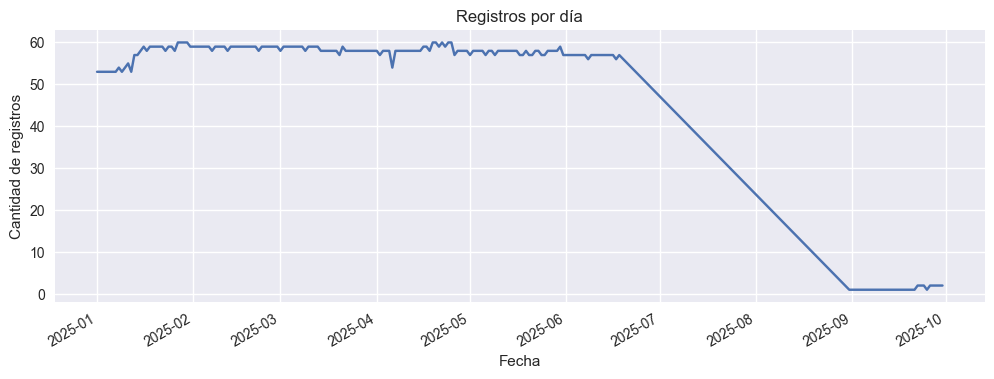

In [4]:
daily_counts = df.groupby("date").size()

plt.figure(figsize=(12, 4))
daily_counts.plot()

plt.title("Registros por día")
plt.ylabel("Cantidad de registros")
plt.xlabel("Fecha")

plt.show()


### Comentarios y observaciones

Una serie relativamente estable sugiere que la ingestión de datos fue consistente.

Hay que poner atención a:

- días completamente vacíos
- caídas bruscas de cobertura
- zonas del tiempo con mucha menos actividad

Si existieran huecos grandes, podrían impactar tanto el EDA como los modelos posteriores.


## 5. Registros por vaca

Aquí se analiza cuántos registros tiene cada vaca dentro del dataset.  
Esto ayuda a detectar animales con muy poca información o con cobertura muy distinta al resto.


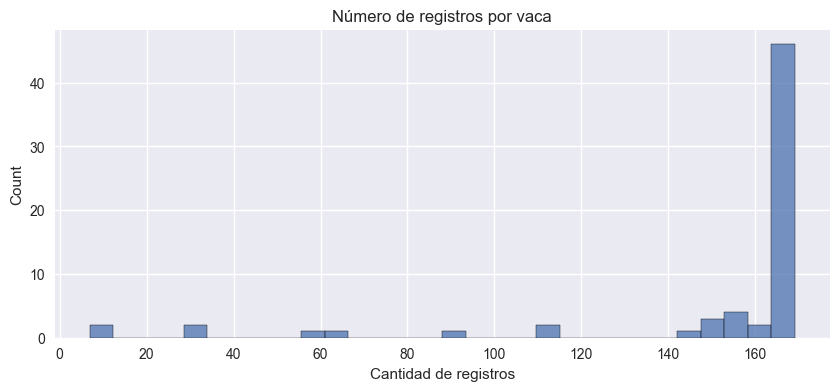

In [5]:
cow_counts = df.groupby("cow_id").size()

plt.figure(figsize=(10, 4))
sns.histplot(cow_counts, bins=30)

plt.title("Número de registros por vaca")
plt.xlabel("Cantidad de registros")

plt.show()


### Comentarios y observaciones

Este histograma permite identificar:

- vacas con historial muy corto
- vacas con cobertura excepcionalmente larga
- distribución desigual entre individuos

Si algunas vacas tienen muy pocos registros, podría convenir filtrarlas o tratarlas con cuidado en etapas de modelado.


## 6.1 Disponibilidad de variables de alimentación

Ahora el dataset también puede incluir variables derivadas de alimentación, por ejemplo:

- `kg_am`
- `kg_pm`
- `kg_totales`
- `sobrante`
- `consumo`
- `rechazo`
- `n_vacas`
- `kg_consumido_por_vaca`
- `promedio_corral`
- `kg_ofrecidos_por_vaca`
- `sobrante_pct`
- `consumo_pct`

En esta sección se revisa cuáles de esas variables están presentes y qué cobertura tienen.


Variables de alimentación presentes: ['kg_am', 'kg_pm', 'kg_totales', 'sobrante', 'consumo', 'rechazo', 'kg_consumido_por_vaca', 'promedio_corral', 'sobrante_pct', 'consumo_pct']


promedio_corral          0.942022
kg_consumido_por_vaca    0.722234
rechazo                  0.227736
sobrante_pct             0.066639
consumo_pct              0.048706
kg_am                    0.041573
kg_pm                    0.041573
consumo                  0.041573
kg_totales               0.041573
sobrante                 0.041573
dtype: float64

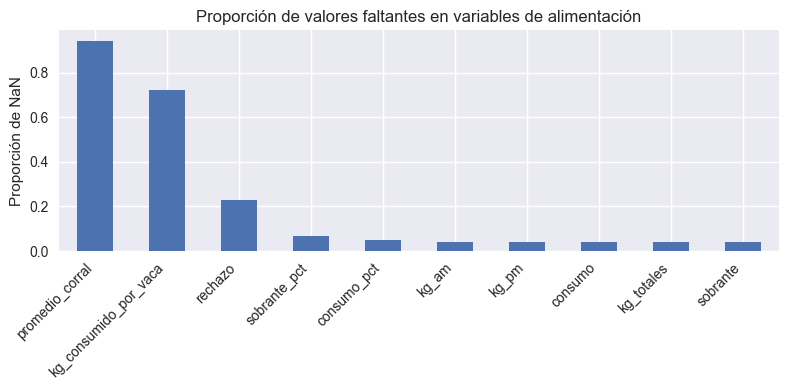

In [6]:
feeding_cols = [
    "kg_am", "kg_pm", "kg_totales", "sobrante", "consumo",
    "rechazo", "n_vacas", "kg_consumido_por_vaca",
    "promedio_corral", "kg_ofrecidos_por_vaca",
    "sobrante_pct", "consumo_pct"
]

feeding_cols_present = [c for c in feeding_cols if c in df.columns]

print("Variables de alimentación presentes:", feeding_cols_present)

if feeding_cols_present:
    feeding_missing = (
        df[feeding_cols_present]
        .isna()
        .mean()
        .sort_values(ascending=False)
    )
    display(feeding_missing)

    plt.figure(figsize=(8, 4))
    feeding_missing.plot.bar()
    plt.title("Proporción de valores faltantes en variables de alimentación")
    plt.ylabel("Proporción de NaN")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron variables de alimentación en este dataset.")


### Comentarios y observaciones

Como la alimentación se integró inicialmente por fecha y no por vaca, estas variables deben interpretarse como contexto diario global del sistema.

Aun así, pueden ser útiles porque reflejan:

- oferta de alimento
- sobrante
- consumo total
- consumo por vaca
- rechazo


## 6.2 Distribución de variables de alimentación

Se visualizan las variables de alimentación disponibles para entender sus rangos, dispersión y posibles valores atípicos.


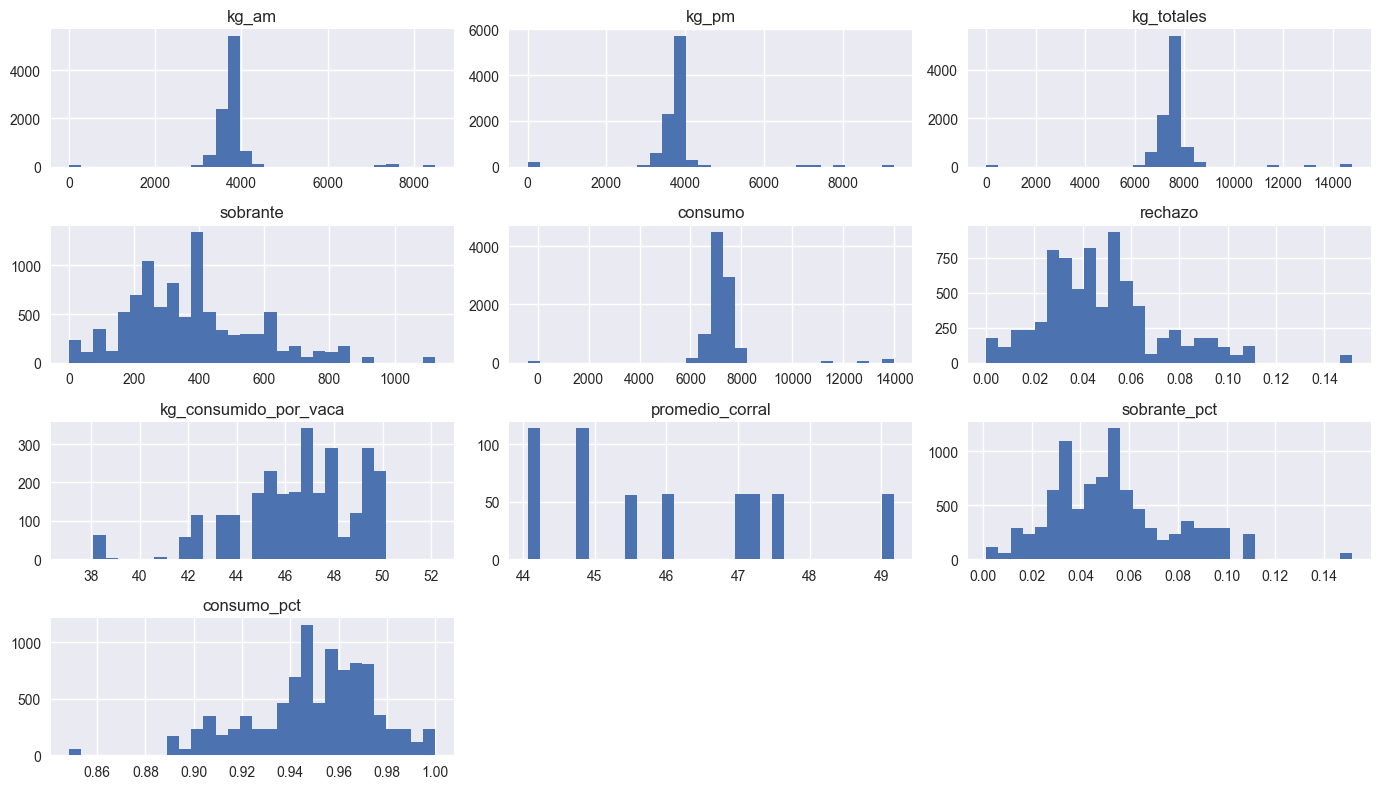

In [7]:
if feeding_cols_present:
    df[feeding_cols_present].hist(
        bins=30,
        figsize=(14, 8)
    )
    plt.tight_layout()
else:
    print("No hay variables de alimentación para graficar.")


### Comentarios y observaciones

Aquí conviene revisar:

- escalas muy distintas entre variables
- valores extremos
- columnas casi constantes
- posibles errores de captura


## 6. Valores faltantes

Se calcula la proporción de valores faltantes por columna para identificar variables completas, parcialmente disponibles o prácticamente vacías.


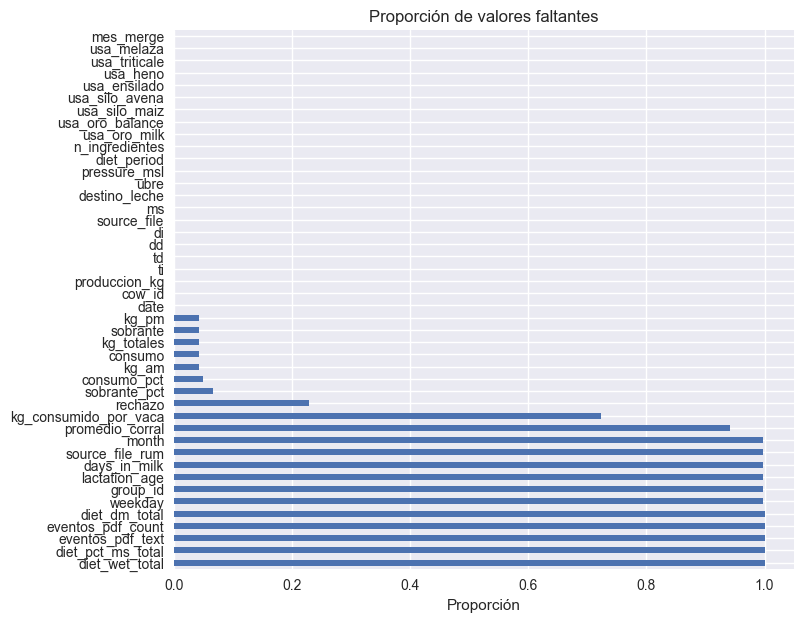

diet_wet_total           1.000000
diet_pct_ms_total        1.000000
eventos_pdf_text         1.000000
eventos_pdf_count        1.000000
diet_dm_total            1.000000
weekday                  0.997147
group_id                 0.997147
lactation_age            0.997147
days_in_milk             0.997147
source_file_rum          0.997147
month                    0.997147
promedio_corral          0.942022
kg_consumido_por_vaca    0.722234
rechazo                  0.227736
sobrante_pct             0.066639
consumo_pct              0.048706
kg_am                    0.041573
consumo                  0.041573
kg_totales               0.041573
sobrante                 0.041573
kg_pm                    0.041573
date                     0.000000
cow_id                   0.000000
produccion_kg            0.000000
ti                       0.000000
td                       0.000000
dd                       0.000000
di                       0.000000
source_file              0.000000
ms            

In [8]:
missing = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 7))
missing.plot.barh()

plt.title("Proporción de valores faltantes")
plt.xlabel("Proporción")

plt.show()

display(missing)


### Comentarios y observaciones

Este análisis es clave para decidir qué variables se pueden usar desde el modelo base y cuáles requieren tratamiento especial.

Preguntas importantes:

- ¿Qué columnas están completas?
- ¿Qué variables tienen cobertura marginal?
- ¿Los faltantes se concentran en sensores o fuentes específicas?
- ¿Conviene imputar, eliminar o separar esas variables?

En este proyecto, variables como rumia o algunos eventos pueden existir solo en un subconjunto pequeño del dataset.


## 7. Distribuciones de variables numéricas

Se grafican histogramas para entender la forma general de las variables cuantitativas.


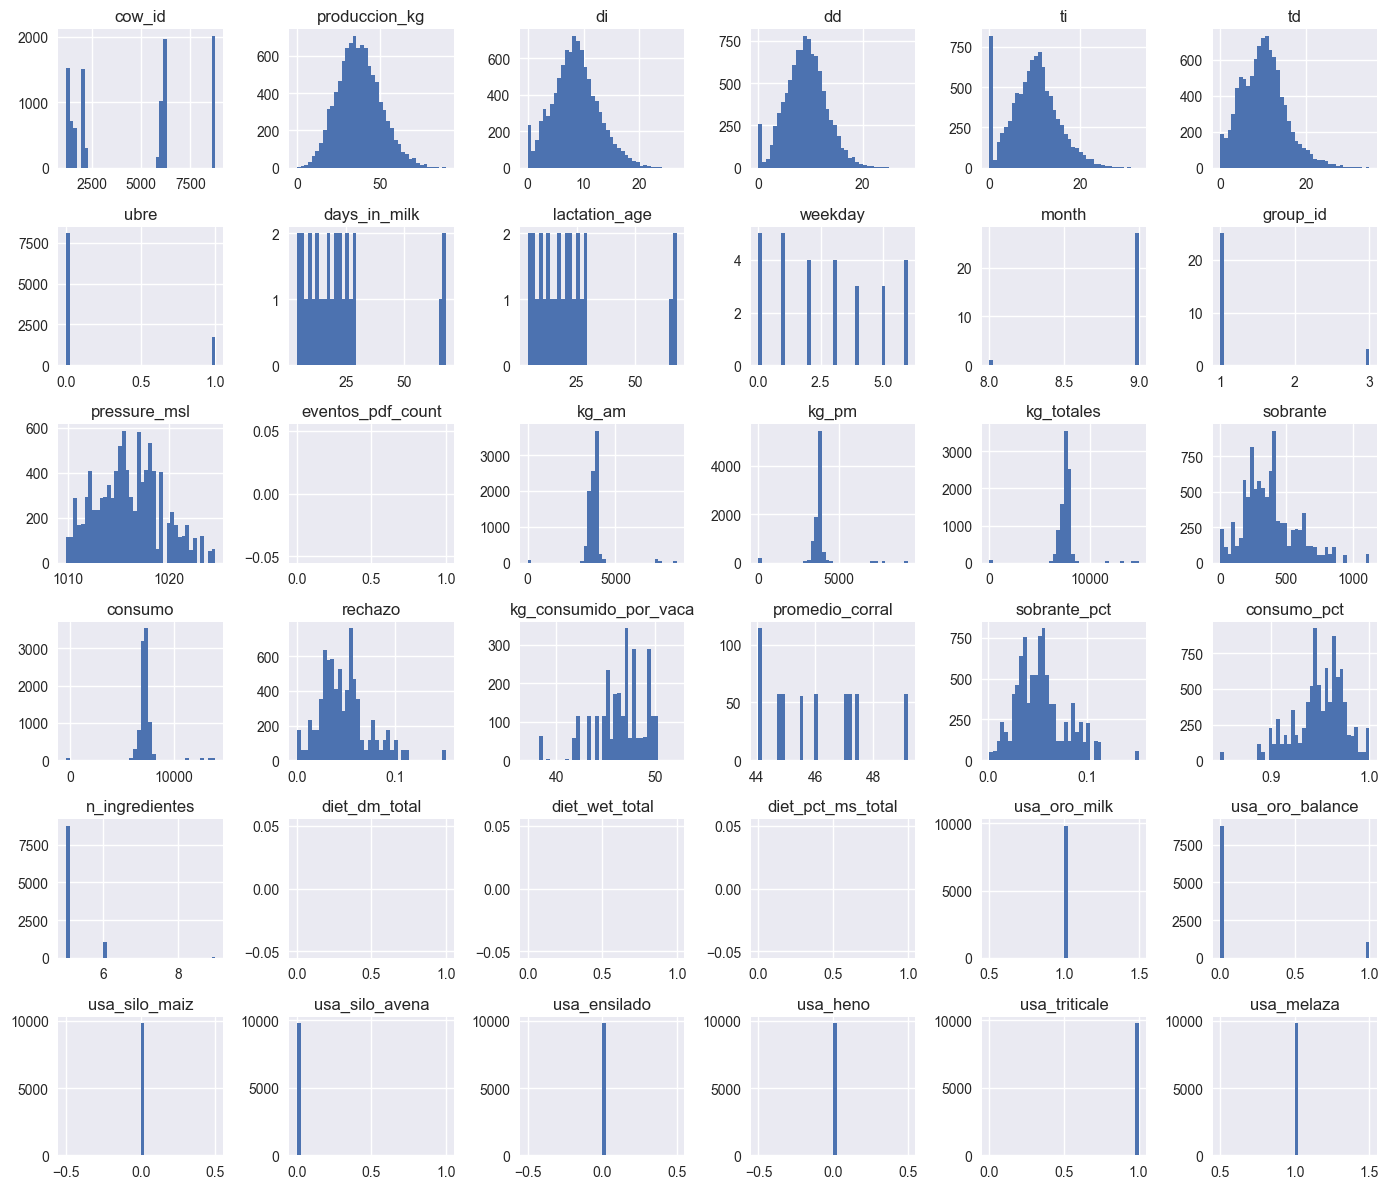

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    bins=40,
    figsize=(14, 12)
)

plt.tight_layout()


### Comentarios y observaciones

Aquí se busca detectar:

- valores atípicos
- distribuciones muy sesgadas
- acumulación en cero
- rangos extraños o poco realistas

Esta revisión ayuda a decidir si algunas variables deben transformarse, recortarse o normalizarse antes del modelado.


## 8. Matriz de correlación

La matriz de correlación permite observar relaciones lineales entre variables numéricas.  
Es útil para detectar grupos de variables redundantes y señales potencialmente útiles para el modelo.


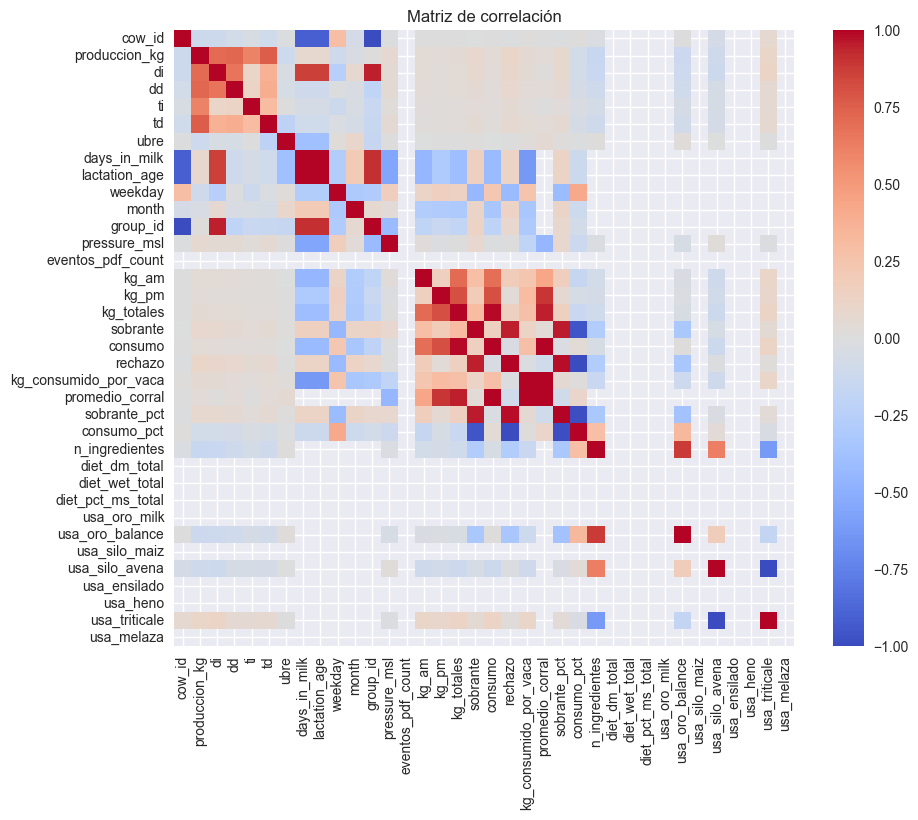

In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Matriz de correlación")
plt.show()


### Comentarios y observaciones

Este gráfico ayuda a identificar:

- variables fuertemente relacionadas con `produccion_kg`
- grupos de variables redundantes
- bloques de comportamiento similar
- relaciones negativas o positivas relevantes

Hay que recordar que esta matriz solo captura relaciones lineales.  
Variables climáticas, por ejemplo, pueden tener efectos no lineales que aquí no se aprecian con claridad.


## 9. Mapa de calor vaca × tiempo para cobertura de datos

Este gráfico no muestra valores de producción, sino simplemente la **presencia o ausencia de registros** por vaca y por fecha.

### ¿Qué representa?

- Eje vertical: identificador de vaca (`cow_id`)
- Eje horizontal: fecha
- Color: existencia de dato en esa combinación vaca-fecha

### ¿Para qué sirve?

- Detectar huecos de ingestión
- Ver vacas con historial incompleto
- Identificar periodos largos sin datos
- Confirmar si el merge final quedó consistente en el tiempo


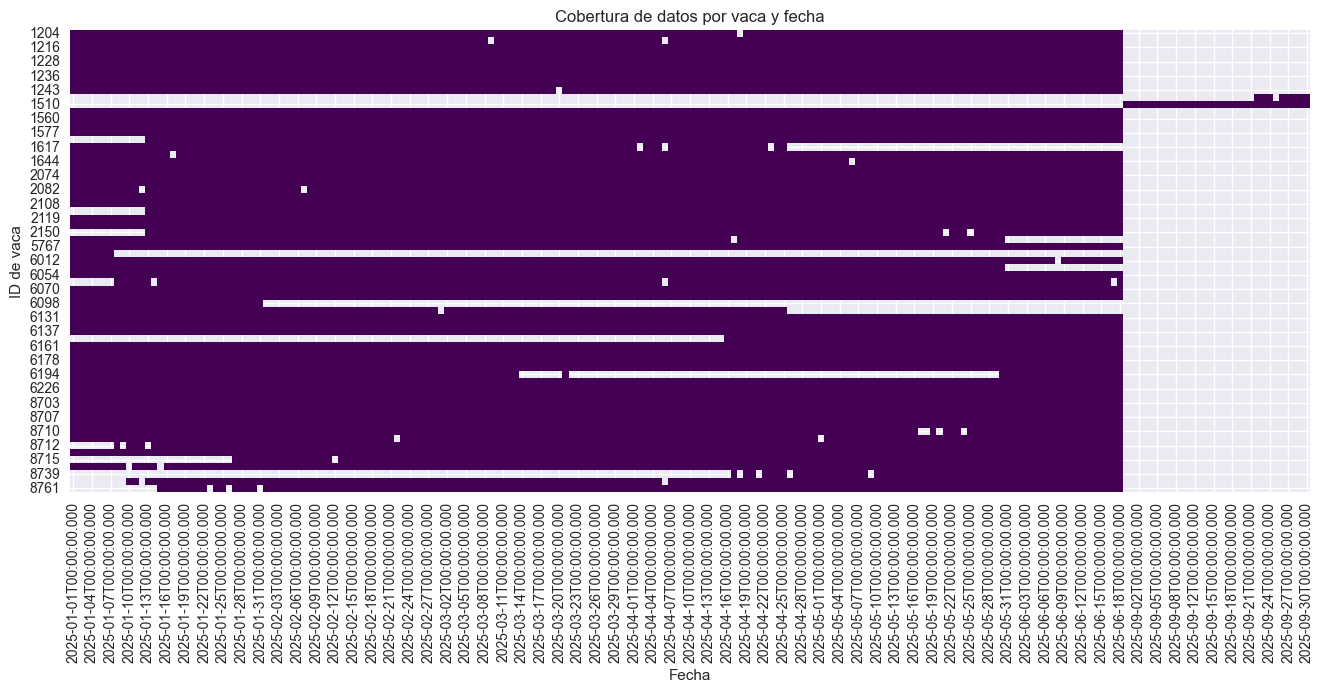

In [11]:
pivot = (
    df.assign(tiene_dato=1)
    .pivot_table(
        index="cow_id",
        columns="date",
        values="tiene_dato",
        aggfunc="max"
    )
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    pivot,
    cmap="viridis",
    cbar=False
)

plt.title("Cobertura de datos por vaca y fecha")
plt.xlabel("Fecha")
plt.ylabel("ID de vaca")

plt.show()


### Comentarios y observaciones

Interpretación general:

- bloques continuos indican buena cobertura
- huecos aislados pueden sugerir caídas puntuales de sensor o ingestión
- huecos largos pueden indicar vacas con historial parcial
- columnas completas vacías sugerirían problemas globales de ingestión en ciertos días

Este gráfico es muy útil para validar que el dataset final mantiene una estructura temporal razonable.


## 10. Mapa de calor de producción de leche por vaca y día

A diferencia del gráfico anterior, aquí sí se visualiza el valor de `produccion_kg` para cada vaca y cada fecha.

### ¿Qué representa?

- Eje vertical: vacas
- Eje horizontal: fechas
- Color: nivel de producción de leche

### ¿Para qué sirve?

- Comparar niveles de producción entre vacas
- Ver curvas temporales de producción
- Detectar caídas abruptas
- Identificar vacas con perfiles de producción muy distintos


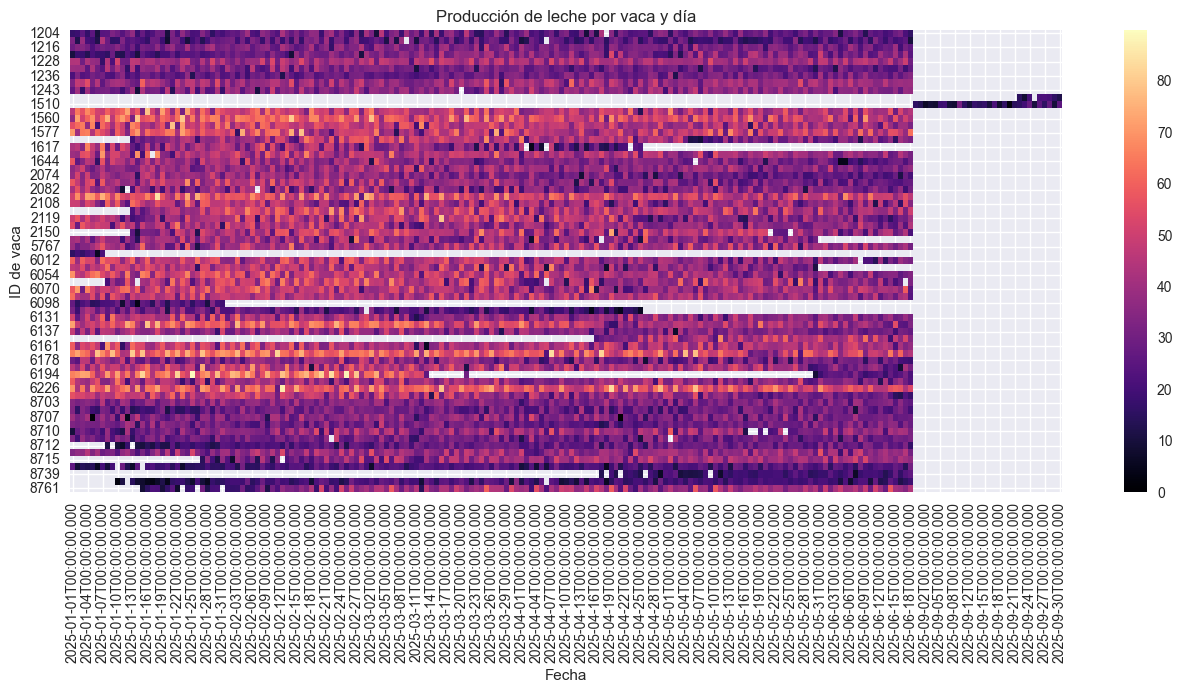

In [12]:
pivot_milk = df.pivot_table(
    index="cow_id",
    columns="date",
    values="produccion_kg"
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    pivot_milk,
    cmap="magma"
)

plt.title("Producción de leche por vaca y día")
plt.xlabel("Fecha")
plt.ylabel("ID de vaca")

plt.show()


### Comentarios y observaciones

Este mapa de calor permite observar:

- vacas consistentemente de alta o baja producción
- posibles curvas de lactancia a lo largo del tiempo
- cambios fuertes de producción en periodos específicos
- posibles anomalías de sensor o eventos biológicos relevantes

Es una visualización especialmente útil para detectar patrones globales del hato que no son evidentes en histogramas o tablas.


## 11. Producción vs días en leche

Este gráfico relaciona `produccion_kg` con `days_in_milk`.

### ¿Qué representa?

Cada punto corresponde a una observación individual.  
En el eje horizontal está el número de días en leche y en el vertical la producción de leche.

### ¿Por qué es importante?

En producción lechera, esta relación suele capturar la **curva de lactancia**, que normalmente sigue un patrón de:

aumento → pico → descenso gradual


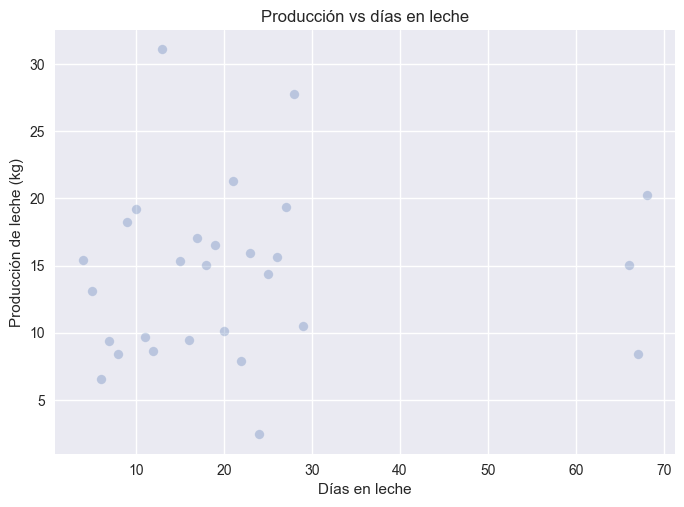

In [13]:
sns.scatterplot(
    data=df,
    x="days_in_milk",
    y="produccion_kg",
    alpha=0.3
)

plt.title("Producción vs días en leche")
plt.xlabel("Días en leche")
plt.ylabel("Producción de leche (kg)")
plt.show()


### Comentarios y observaciones

Si `days_in_milk` tiene buena cobertura, esta suele ser una de las variables más importantes para modelar producción.

Aquí conviene observar:

- forma general de la nube de puntos
- posible pico de producción
- dispersión entre vacas
- presencia de valores extremos

Si esta variable tiene muchos faltantes, su utilidad práctica dependerá de si más adelante se puede reconstruir o enriquecer.


## 12. Producción promedio del hato a lo largo del tiempo

Este gráfico resume la producción promedio diaria considerando todas las vacas disponibles en cada fecha.

### ¿Para qué sirve?

- Detectar tendencias globales del hato
- Ver cambios colectivos de producción
- Identificar días anómalos
- Explorar efectos temporales agregados


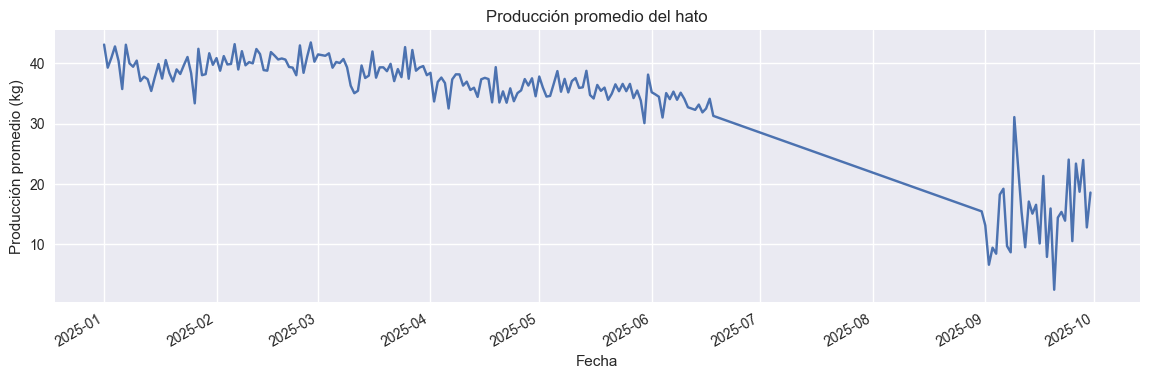

In [14]:
daily_milk = df.groupby("date")["produccion_kg"].mean()

plt.figure(figsize=(14, 4))
daily_milk.plot()

plt.title("Producción promedio del hato")
plt.ylabel("Producción promedio (kg)")
plt.xlabel("Fecha")

plt.show()


### Comentarios y observaciones

Este gráfico ayuda a responder preguntas como:

- ¿la producción promedio sube o baja con el tiempo?
- ¿existen caídas abruptas colectivas?
- ¿hay periodos de comportamiento anómalo?

Cuando se analizan modelos de predicción, esta vista agregada puede ser muy útil para entender el contexto temporal general del sistema.


## 13. Conclusiones generales del EDA

A partir de las visualizaciones y estadísticas exploradas en este notebook se pueden extraer las siguientes conclusiones.


## 12.1 Producción vs alimentación

Esta sección revisa relaciones simples entre producción de leche y algunas variables de alimentación.


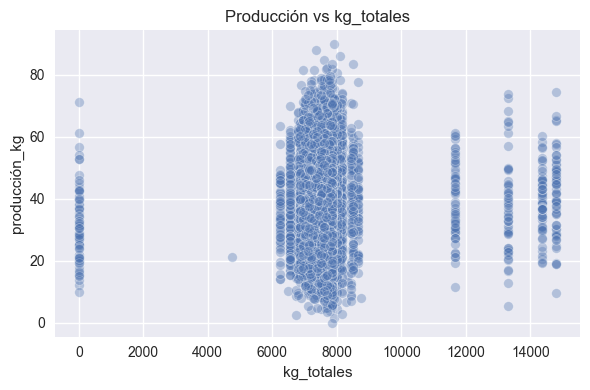

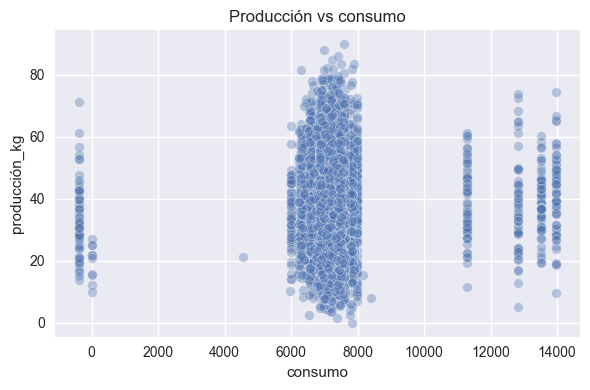

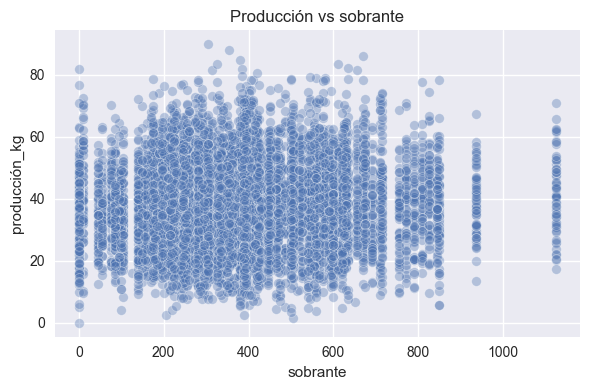

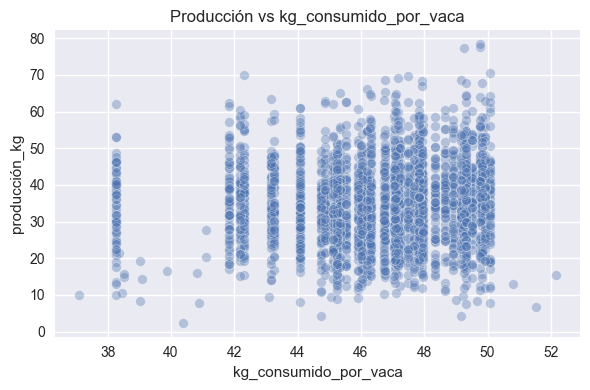

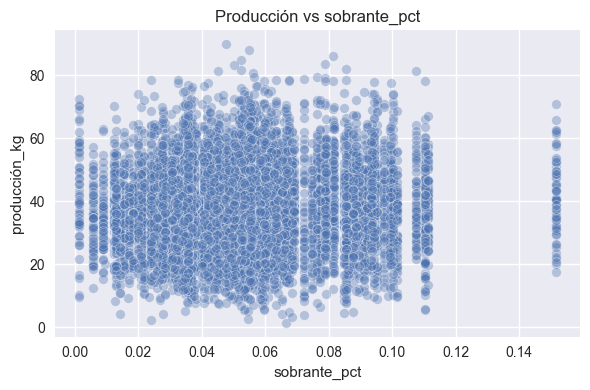

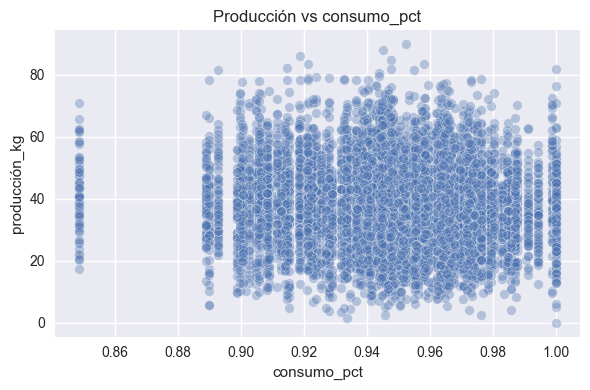

In [15]:
candidate_feed_plots = [
    "kg_totales",
    "consumo",
    "sobrante",
    "kg_consumido_por_vaca",
    "kg_ofrecidos_por_vaca",
    "sobrante_pct",
    "consumo_pct",
]

candidate_feed_plots = [c for c in candidate_feed_plots if c in df.columns]

for col in candidate_feed_plots[:6]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="produccion_kg", alpha=0.35)
    plt.title(f"Producción vs {col}")
    plt.xlabel(col)
    plt.ylabel("producción_kg")
    plt.tight_layout()
    plt.show()


### Comentarios y observaciones

Estas gráficas no prueban causalidad, pero ayudan a detectar si la producción parece responder a patrones de oferta, consumo o sobrante.


### 1. Integridad del dataset

- El dataset tiene una estructura general consistente.
- Las variables principales como `produccion_kg`, `cow_id` y `date` muestran buena disponibilidad.
- El pipeline de integración parece suficientemente estable para continuar con etapas posteriores.


### 2. Cobertura temporal

- La cobertura por fecha es razonablemente estable.
- No se observan fallos globales masivos de ingestión dentro del periodo principal analizado.
- Algunas vacas muestran huecos o historiales parciales, lo cual es normal pero debe considerarse en modelado.


### 3. Producción de leche

- Existen diferencias claras de producción entre vacas.
- Se observan patrones temporales coherentes con comportamiento biológico real.
- La producción no parece ser ruido puro; el dataset contiene señal útil para aprendizaje automático.


### 4. Variables faltantes

- Algunas variables tienen cobertura casi completa y son buenas candidatas para el modelo base.
- Otras variables, como `rumia_min`, `days_in_milk`, `lactation_age` o algunas asociadas a eventos, tienen cobertura muy limitada.
- Estas variables podrían excluirse del modelo base o usarse solo en análisis especializados.


### 5. Valor de las visualizaciones temporales

Los mapas de calor vaca × tiempo resultaron especialmente útiles porque permiten:

- validar cobertura
- detectar huecos
- identificar vacas con historia incompleta
- observar cambios temporales de producción


## 14. Próximos pasos sugeridos

Después de este EDA, los siguientes pasos recomendados son:

1. limpieza final de variables con demasiados faltantes
2. ingeniería de variables
3. generación de variables con rezago temporal
4. promedios móviles por vaca
5. variables derivadas de clima, como índices de estrés térmico
6. preparación del dataset para entrenamiento de modelos

Este EDA confirma que el dataset base es utilizable y que ya contiene estructura suficiente para comenzar el desarrollo del pipeline de modelado.
